In [1]:
import joblib
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
data = joblib.load("../data/processed/model_ready_v1.pkl")
X_train, y_train = data["X_train"], data["y_train"]
X_test, y_test = data["X_test"], data["y_test"]
train_meta, test_meta = data["train_meta"], data["test_meta"]

In [3]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

models = {
    "LinearRegression (baseline)": LinearRegression(),
    "RandomForest": RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1),
    "XGBoost": XGBRegressor(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42, n_jobs=-1),
}

results = []
fitted_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    results.append({
        "model": name,
        "MAE": mean_absolute_error(y_test, preds),
        "RMSE": np.sqrt(mean_squared_error(y_test, preds)),
        "R2": r2_score(y_test, preds),
    })
    fitted_models[name] = model

results_df = pd.DataFrame(results).sort_values("MAE")
print(results_df)

                         model        MAE       RMSE        R2
2                      XGBoost  33.263250  60.943480  0.114779
1                 RandomForest  35.412763  63.581846  0.036474
0  LinearRegression (baseline)  35.744179  63.029701  0.053135


### Hyperparameter Tuning

In [4]:
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit

param_dist = {
    "n_estimators": [100, 200, 300],
    "max_depth": [4, 6, 8, 10],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "subsample": [0.7, 0.85, 1.0],
}

tscv = TimeSeriesSplit(n_splits=3)

search = RandomizedSearchCV(
    XGBRegressor(random_state=42, n_jobs=-1),
    param_distributions=param_dist,
    n_iter=15,
    scoring="neg_mean_absolute_error",
    cv=tscv,
    random_state=42,
    n_jobs=-1,
    verbose=1,
)
search.fit(X_train, y_train)

print("Best params:", search.best_params_)
print("Best CV MAE:", -search.best_score_)

Fitting 3 folds for each of 15 candidates, totalling 45 fits
Best params: {'subsample': 0.7, 'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.05}
Best CV MAE: 24.496520297468862


In [5]:
best_model = search.best_estimator_
preds = best_model.predict(X_test)

tuned_mae = mean_absolute_error(y_test, preds)
tuned_rmse = np.sqrt(mean_squared_error(y_test, preds))
tuned_r2 = r2_score(y_test, preds)

print(f"Tuned model — MAE: {tuned_mae:.2f} min, RMSE: {tuned_rmse:.2f} min, R2: {tuned_r2:.3f}")
print(f"Improvement over Day 3 default: {results_df.iloc[0]['MAE'] - tuned_mae:.2f} min")

Tuned model — MAE: 32.89 min, RMSE: 60.55 min, R2: 0.126
Improvement over Day 3 default: 0.37 min


In [6]:
eval_df = test_meta.copy()
eval_df["actual"] = y_test.values
eval_df["predicted"] = preds
eval_df["abs_error"] = (eval_df["actual"] - eval_df["predicted"]).abs()

print("By station_code (top 10 worst):")
print(eval_df.groupby("station_code")["abs_error"].mean().sort_values(ascending=False).head(10))

print("\nBy month:")
print(eval_df.groupby("month")["abs_error"].mean())

print("\nBy rain_category:")
print(eval_df.groupby("rain_category")["abs_error"].mean())

By station_code (top 10 worst):
station_code
PERN    54.114838
KRMI    48.006932
THVM    43.523389
PNVL    40.124305
CSMT    40.067284
RN      39.517151
CHI     39.037336
KUDL    38.787195
KYN     38.535066
SGR     38.505116
Name: abs_error, dtype: float64

By month:
month
1     33.763851
2     45.744961
12    25.116486
Name: abs_error, dtype: float64

By rain_category:
rain_category
No rain    29.648684
Unknown    38.317448
Name: abs_error, dtype: float64


In [7]:
from pathlib import Path

Path("../models").mkdir(parents=True, exist_ok=True)
joblib.dump(best_model, "../models/delay_model_v1.pkl")
joblib.dump(list(X_train.columns), "../models/feature_columns_v1.pkl")
print("Saved to ../models/")

Saved to ../models/


## SHAP Interpretations

In [8]:
import shap
import matplotlib.pyplot as plt
from pathlib import Path

C:\Users\Shreya\Desktop\Kokan-Railway-Delay-Analysis\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [9]:
X_test_sample = X_test.sample(2000, random_state=42)

explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test_sample)

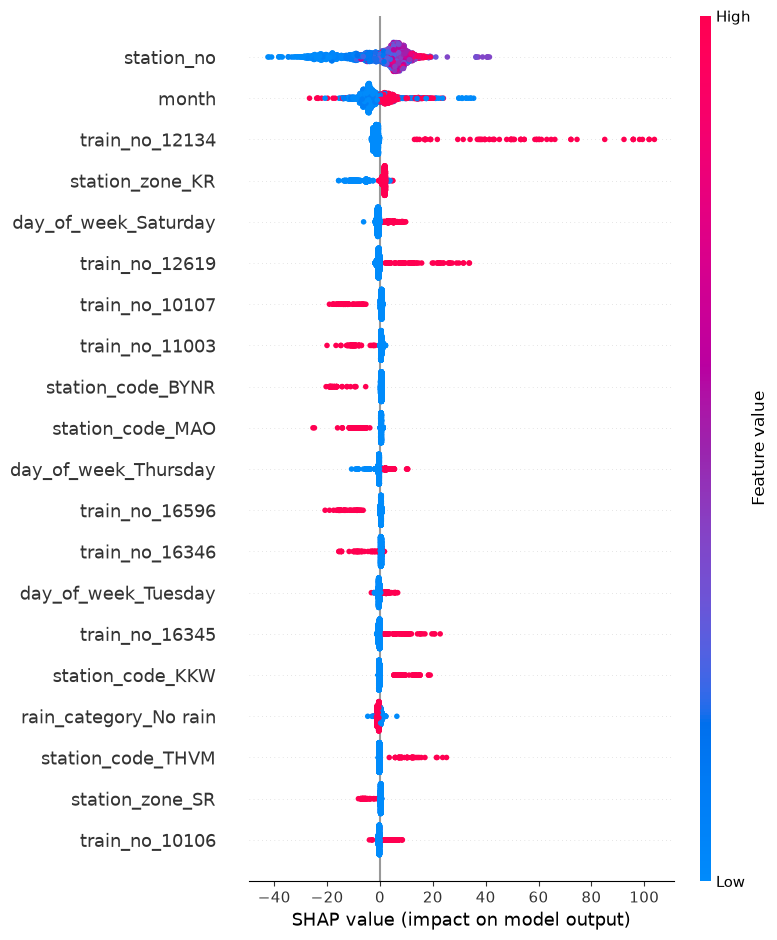

In [10]:
Path("../models").mkdir(parents=True, exist_ok=True)

shap.summary_plot(shap_values, X_test_sample, show=False)
plt.savefig("../models/shap_summary.png", bbox_inches="tight", dpi=150)
plt.show()

In [11]:
eval_sample = test_meta.loc[X_test_sample.index].copy()
eval_sample["actual"] = y_test.loc[X_test_sample.index].values
eval_sample["predicted"] = best_model.predict(X_test_sample)
eval_sample["err"] = eval_sample["actual"] - eval_sample["predicted"]

worst_underpredict = eval_sample.sort_values("err", ascending=False).index[0]
highest_actual_delay = eval_sample["actual"].idxmax()


Worst under-prediction: actual=590 min, predicted=60 min


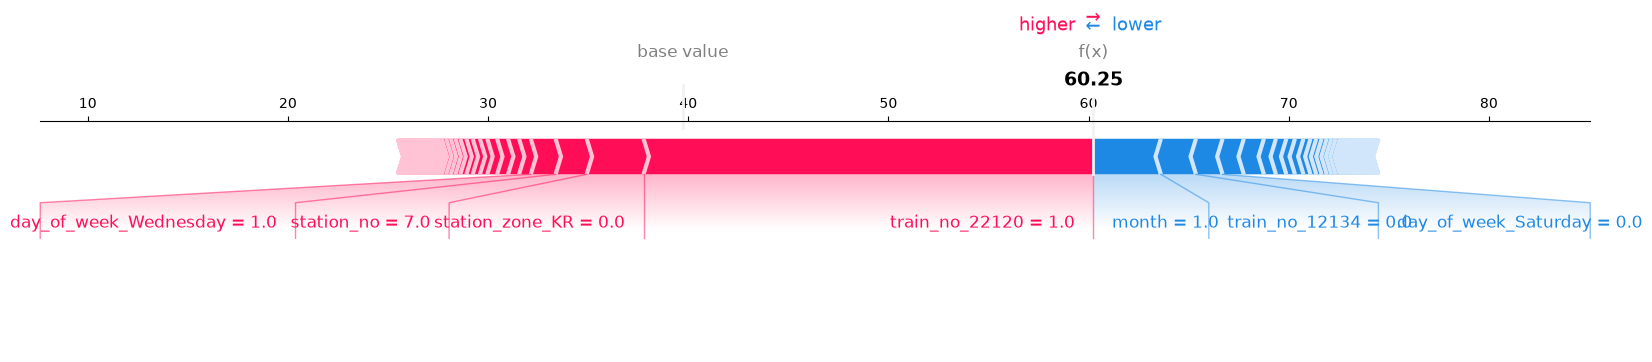


Highest actual delay: actual=590 min, predicted=60 min


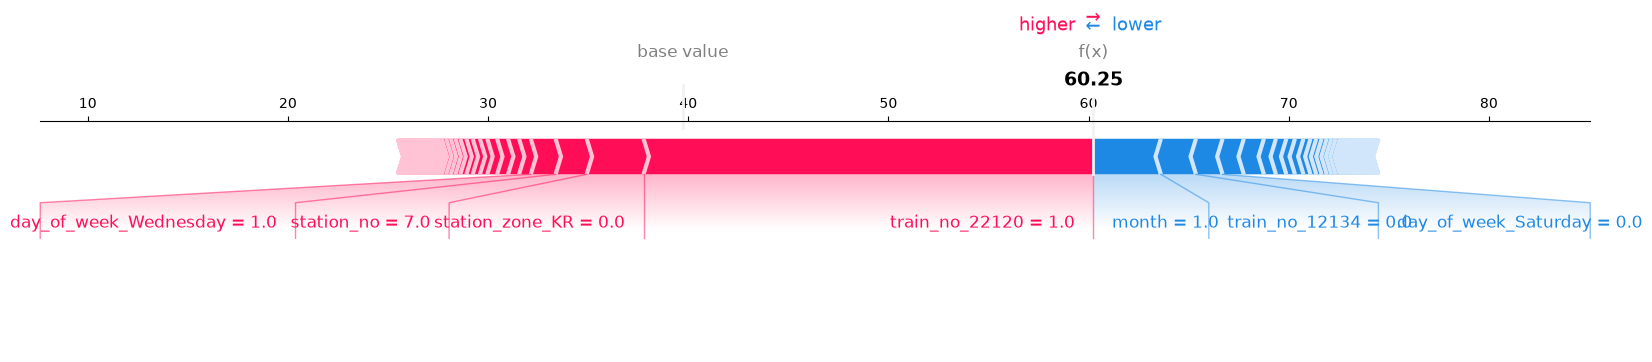

In [12]:
for label, idx in [("Worst under-prediction", worst_underpredict), ("Highest actual delay", highest_actual_delay)]:
    print(f"\n{label}: actual={eval_sample.loc[idx, 'actual']:.0f} min, "
         f"predicted={eval_sample.loc[idx, 'predicted']:.0f} min")
    pos = X_test_sample.index.get_loc(idx)
    shap.force_plot(
        explainer.expected_value,
        shap_values[pos],
        X_test_sample.iloc[pos],
        matplotlib=True,
        show=False
    )
    plt.savefig(f"../models/shap_force_{label.replace(' ', '_').lower()}.png", bbox_inches="tight", dpi=150)
    plt.show()

In [13]:
joblib.dump(explainer, "../models/shap_explainer_v1.pkl")
joblib.dump(shap_values, "../models/shap_values_sample_v1.pkl")
print("SHAP explainer and sample values saved to ../models/")

SHAP explainer and sample values saved to ../models/


In [14]:
importance = pd.DataFrame({
    "feature": X_test_sample.columns,
    "mean_abs_shap": np.abs(shap_values).mean(axis=0)
}).sort_values("mean_abs_shap", ascending=False)

print("Top 15 Most Important Features by Mean |SHAP|:")
print(importance.head(15))

Top 15 Most Important Features by Mean |SHAP|:
                  feature  mean_abs_shap
0              station_no       8.951530
1                   month       4.834493
78         train_no_12134       3.197099
123       station_zone_KR       2.686881
113  day_of_week_Saturday       1.304837
85         train_no_12619       1.068931
71         train_no_10107       1.015007
75         train_no_11003       0.952543
13      station_code_BYNR       0.895616
35       station_code_MAO       0.852032
115  day_of_week_Thursday       0.819998
96         train_no_16596       0.705076
90         train_no_16346       0.633121
116   day_of_week_Tuesday       0.630264
89         train_no_16345       0.624688


In [15]:
joblib.dump(X_test_sample, "../models/shap_X_sample_v1.pkl")

importance = pd.DataFrame({
    "feature": X_test_sample.columns,
    "mean_abs_shap": np.abs(shap_values).mean(axis=0)
}).sort_values("mean_abs_shap", ascending=False)
importance.to_csv("../models/shap_importance_v1.csv", index=False)
print("Saved shap_X_sample_v1.pkl and shap_importance_v1.csv")

Saved shap_X_sample_v1.pkl and shap_importance_v1.csv
